In [1]:
import os
import chemiscope
import ipi
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
import nqetools as nqe
# This follows:
# https://atomistic-cookbook.org/examples/path-integrals/path-integrals.html

In [2]:
# Make a directory to store everything
directory_md = "md"
directory_piglet = "piglet"
directory_pimd = "pimd"
n_beads = 8
timestep = 0.5
total_steps = 200
stride = 1
temperature = 298

In [ ]:
# build the molecule
atoms = read("water_32.pdb")
atoms.center(vacuum=0.0)
# Set PBC
atoms.set_pbc([True, True, True])
# atoms = nqe.read_ipi_xyz("water_32.pdb")[-1]

In [ ]:
# Make sure the directory is empty
nqe.remove_directory(directory_pimd)
# Run the calculation
nqe.run_md(directory_pimd, atoms, driver='ase-mace', total_steps=total_steps, temperature=temperature,
           timestep=timestep, md_type="NVT", stride=stride, n_beads=n_beads, xml_in="input_pimd.xml")

In [ ]:
# Read the results
# drops first frame where all atoms overlap
output_data, output_desc = ipi.read_output(os.path.join(directory_pimd, "md.out"))
traj_data = [ipi.read_trajectory(os.path.join(directory_pimd, f"md.pos_{i}.xyz"))[1:] for i in range(n_beads)]

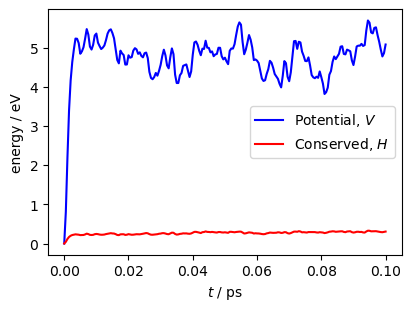

In [6]:
fix, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(
    output_data["time"],
    output_data["potential"] - output_data["potential"][0],
    "b-",
    label="Potential, $V$",
)
ax.plot(
    output_data["time"],
    output_data["conserved"] - output_data["conserved"][0],
    "r-",
    label="Conserved, $H$",
)
ax.set_xlabel(r"$t$ / ps")
ax.set_ylabel(r"energy / eV")
ax.legend()
plt.show()
# https://github.com/lab-cosmo/chemiscope/issues/390

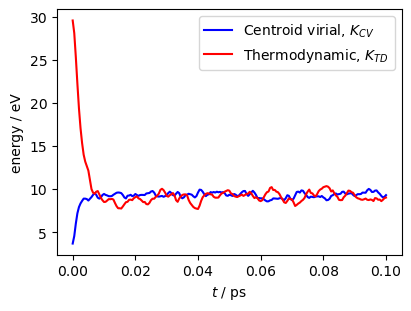

In [7]:
fix, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(
    output_data["time"],
    output_data["kinetic_cv"],
    "b-",
    label="Centroid virial, $K_{CV}$",
)
ax.plot(
    output_data["time"],
    output_data["kinetic_td"],
    "r-",
    label="Thermodynamic, $K_{TD}$",
)
ax.set_xlabel(r"$t$ / ps")
ax.set_ylabel(r"energy / eV")
ax.legend()
plt.show()

In [19]:
traj_pimd = chemiscope.ase_merge_pi_frames(traj_data)
# we also tweak the visualization options, and then show the viewer
traj_pimd["shapes"]["paths"]["parameters"]["global"]["radius"] = 0.05
traj_pimd["settings"]["structure"][0].update(
    dict(
        atoms=False,
        keepOrientation=True,
        color={"property": "bead_id", "palette": "hsv (periodic)"},
    )
)

widget=chemiscope.show(**traj_pimd, mode="structure")

widget.save("showcase.json.gz")


In [9]:
# Make sure the directory is empty
nqe.remove_directory(directory_piglet)
# Run the calculation
nqe.run_md(directory_piglet, atoms, driver='ase-mace', total_steps=200, temperature=298, timestep=0.5, md_type="NVT",
           stride=1, n_beads=n_beads, xml_in="input_piglet.xml")

The directory piglet does not exist.
Running the MD (NVT) with the driver: python3 run-ase-mace.py

 ____       ____       ____       ____
/    \     /    \     /    \     /    \
|  #################################  |
\__#_/     \____/     \____/     \_#__/
   #    _        _______  _____    #
   #   (_)      |_   __ \|_   _|   #      -*-   v 3.1  -*-
   #   __  ______ | |__) | | |     #
   Y  [  ||______||  ___/  | |     #      A Universal Force Engine
  0 0  | |       _| |_    _| |_    #
   #  [___]     |_____|  |_____|   #
 __#_       ____       ____       _#__
/  # \     /    \     /    \     / #  \
|  #################################  |
\____/     \____/     \____/     \____/

    
 @system: Initializing system object 
 @simulation: Initializing simulation object 
@ RANDOM SEED: The seed used in this calculation was 32342
 @init_file: Initializing from file init.xyz. Dimension: length, units: angstrom, cell_units: automatic
 @set_vector: Initialize is rescaling from     1 beads 

/home/louie/anaconda3/envs/ipi_env2/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = torch.lo

Using MACE-OFF23 MODEL for MACECalculator with /home/louie/.cache/mace/MACE-OFF23_small.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.

 ---  end input file content  ---
 @system.bind: Binding the forces 
Import of PyFFTW successful
 GLE additional DOFs initialised to the free-particle limit.
GLE additional DOFs initialised from input.
GLE additional DOFs initialised from input.
GLE additional DOFs initialised from input.
GLE additional DOFs initialised from input.
GLE additional DOFs initialised from input.
GLE additional DOFs initialised from input.
GLE additional DOFs initialised from input.
GLE additional DOFs initialised from input.
 @interfacesocket.open: Created unix socket with address driver
 @ForceField (driver): Starting the polling thread main loop.
 @interfacesocket.pool_update:   Client asked for con

[Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, 

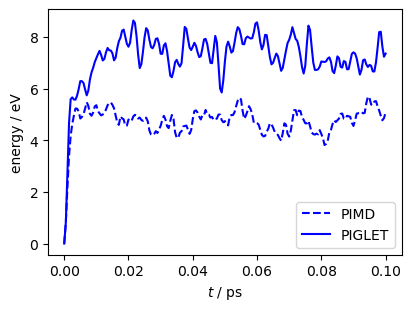

In [10]:
# drops first frame
output_gle, desc_gle = ipi.read_output(os.path.join(directory_piglet, "md.out"))
traj_gle = [ipi.read_trajectory(os.path.join(directory_piglet, f"md.pos_{i}.xyz"))[1:] for i in range(8)]

fig, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(
    output_data["time"],
    output_data["potential"] - output_data["potential"][0],
    "b--",
    label="PIMD",
)
ax.plot(
    output_gle["time"],
    output_gle["potential"] - output_gle["potential"][0],
    "b-",
    label="PIGLET",
)
ax.set_xlabel(r"$t$ / ps")
ax.set_ylabel(r"energy / eV")
ax.legend()
plt.show()

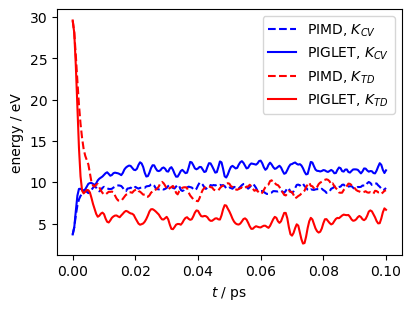

In [11]:
fix, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(output_data["time"], output_data["kinetic_cv"], "b--", label="PIMD, $K_{CV}$")
ax.plot(output_gle["time"], output_gle["kinetic_cv"], "b", label="PIGLET, $K_{CV}$")
ax.plot(output_data["time"], output_data["kinetic_td"], "r--", label="PIMD, $K_{TD}$")
ax.plot(output_gle["time"], output_gle["kinetic_td"], "r", label="PIGLET, $K_{TD}$")
ax.set_xlabel(r"$t$ / ps")
ax.set_ylabel(r"energy / eV")
ax.legend()
plt.show()

In [12]:
kinetic_cv = ipi.read_trajectory(os.path.join(directory_piglet, "md.kin.xyz"))[1:]
kinetic_od = ipi.read_trajectory(os.path.join(directory_piglet,"md.kod.xyz"))[1:]
kinetic_tens = np.hstack(
    [
        np.asarray([k.positions for k in kinetic_cv[-10:]]).mean(axis=0),
        np.asarray([k.positions for k in kinetic_od[-10:]]).mean(axis=0),
    ]
)

centroid = traj_gle[-1][-1].copy()
centroid.positions = np.asarray([t[-1].positions for t in traj_gle]).mean(axis=0)
centroid.arrays["kinetic_cv"] = kinetic_tens

In [26]:
ellipsoids = chemiscope.ase_tensors_to_ellipsoids(
    [centroid], "kinetic_cv", scale=15, force_positive=True
)

widget = chemiscope.show(
    frames=[centroid],
    shapes={"kinetic_cv": ellipsoids},
    mode="structure",
    settings=chemiscope.quick_settings(
        structure_settings={
            "shape": ["kinetic_cv"],
            "unitCell": True,
        }
    ),
    properties=chemiscope.extract_properties([centroid], only=["kinetic_cv"]),
)
widget.save("showcase.json.gz")